In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import argparse
from nnfabrik.builder import get_data, get_trainer

from modified_neuralpredictors.create_model import stacked_core_full_gauss_readout
from modified_neuralpredictors.wandb_trainer import standard_trainer
from models.whitener import Whitener
from utils.knn import get_curve

random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = 'cuda:7'
torch.cuda.set_device(device)

basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"

# as filenames, we'll select all 7 datasets
filenames = [
    os.path.join(basepath, file) for file in os.listdir(basepath) if ".zip" in file
]

dataset_fn = "sensorium.datasets.static_loaders"
dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": True,
    "include_eye_position": True,
    "batch_size": 128,
    "scale": 0.25,
}

dataloaders = get_data(dataset_fn, dataset_config)
data_keys = list(dataloaders['train'].keys())

model_config = {
    'hidden_channels': 64, # original sensorium was 64ch
    'depth_separable': False,
    'use_avg_reg': False,
    'laplace_padding': None,
    'momentum': 0.75,
    'final_nonlinearity': True,
    'nonlinearity_type': 'AdaptiveELU',
    'pad_input': False,
    'stack': -1,
    'layers': 4,
    'input_kern': 11, #  original sensorium was 'input_kern': 9,
    'gamma_input': 6.3831, # this should not influence the performance based on previous experience
    
    'feature_reg_weight': 3, # this is the one I actually would like to tune!
    
    'hidden_kern': 7,
    'grid_mean_predictor': {
        'type': 'cortex',
        'input_dimensions': 2,
        'hidden_layers': 1,
        'hidden_features': 30,
        'final_tanh': True
    },
    
    'init_sigma': 0.1,
    'init_mu_range': 0.3,
    'gauss_type': 'full',
    'shifter': True,
    'batch_norm_scale': [True, True, True, False],
    'core_bias': [True, True, True, False],
    'regularizer_type': "adaptive_log_norm",
    'gamma_sigma' : 0.25,
    'whitener': Whitener(64, 0.0),
}

In [2]:
paths64 = [
    'runs/whitened/regw3_seed0/model_weights.pth',
    'runs/whitened/regw3_seed42/model_weights.pth',
    'runs/whitened/regw3_seed123/model_weights.pth',
]
paths96 = [
    'runs/whitened/white_dim96_seed0/model_weights.pth',
    'runs/whitened/white_dim96_seed42/model_weights.pth',
    'runs/whitened/white_dim96_seed123/model_weights.pth',
]
paths128 = [
    'runs/whitened/white_dim128_seed0/model_weights.pth',
    'runs/whitened/white_dim128_seed42/model_weights.pth',
    'runs/whitened/white_dim128_seed123/model_weights.pth',
]

model_config96 = model_config.copy()
model_config96['hidden_channels'] = 96
model_config96['whitener'] = Whitener(96, 0.0)

model_config128 = model_config.copy()
model_config128['hidden_channels'] = 128
model_config128['whitener'] = Whitener(128, 0.0)

In [ ]:
readouts64 = []
for path in paths64:
    model = stacked_core_full_gauss_readout(dataloaders, random_seed, **model_config)
    model.load_state_dict(torch.load(path, map_location=device))
    model.core.train()
    model.readout.eval()
    readouts64.append(torch.concat([model.readout[key].features.detach().cpu().squeeze().T for key in data_keys]))

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


In [4]:
readouts96 = []
for path in paths96:
    model = stacked_core_full_gauss_readout(dataloaders, random_seed, **model_config96)
    model.load_state_dict(torch.load(path, map_location=device))
    model.core.train()
    model.readout.eval()
    readouts96.append(torch.concat([model.readout[key].features.detach().cpu().squeeze().T for key in data_keys]))

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


In [5]:
readouts128 = []
for path in paths128:
    model = stacked_core_full_gauss_readout(dataloaders, random_seed, **model_config128)
    model.load_state_dict(torch.load(path, map_location=device))
    model.core.train()
    model.readout.eval()
    readouts128.append(torch.concat([model.readout[key].features.detach().cpu().squeeze().T for key in data_keys]))

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


In [6]:
k_range = np.unique(np.geomspace(1, 100, num=20, dtype=int))
curves64 = get_curve(readouts64, k_range)
curves96 = get_curve(readouts96, k_range)
curves128 = get_curve(readouts128, k_range)

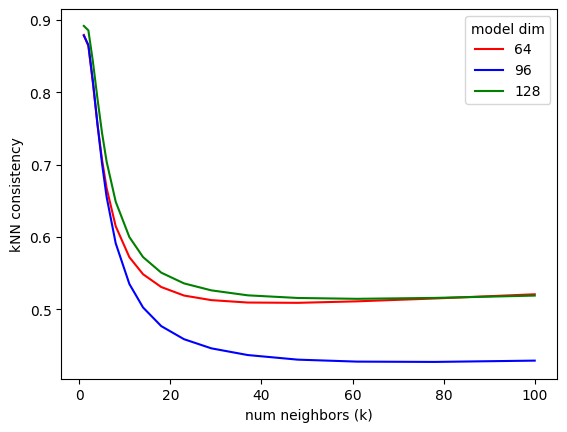

In [31]:
for curves, label, color in zip([curves64, curves96, curves128], [64, 96, 128], ['red', 'blue', 'green']):
    if label == 64:
        curve = curves[2][:, 0].T 
    elif label == 96:
        curve = curves[2][:, 0].T
    elif label == 128:
        curve = curves[2][:, 1].T
    plt.plot(k_range, curve, label=label, color=color)
    # plt.fill_between(k_range, curves[0]-curves[1], curves[0]+curves[1], color=color, alpha=0.2)
plt.legend(title='model dim')
plt.ylabel('kNN consistency')
plt.xlabel('num neighbors (k)')
plt.show()

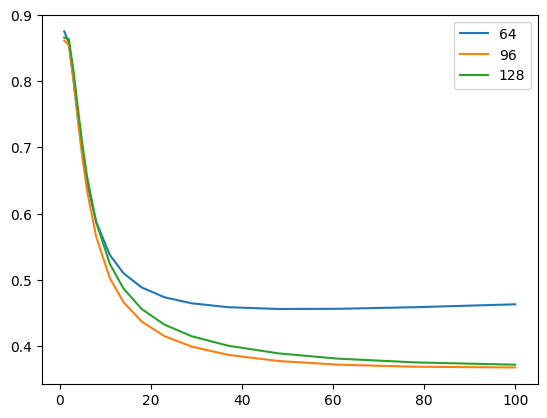

In [ ]:
for curves, label in zip([curves64, curves96, curves128], [64, 96, 128]):
    plt.plot(k_range, curves[0], label=label)
plt.legend()